# Assignment No.3
## Brazilian Marketplace Olist
### Negar Fathi 400222069

#### 1. Data Loading and Overview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import RobustScaler
from functools import reduce
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
product_translation = pd.read_csv('product_category_name_translation.csv')

geolocation = pd.read_csv('olist_geolocation_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')

In [ ]:
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", order_payments.shape)
print("Reviews:", order_reviews.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Product Translation:", product_translation.shape)

print("Geographical Location", geolocation.shape)
print("Sellers:", sellers.shape)

Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Product Translation: (71, 2)
Geographical Location (821361, 5)
Sellers: (3095, 4)


In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
order_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
product_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
product_translation.isnull().sum()

,0
product_category_name,0
product_category_name_english,0


In [ ]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
geolocation.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,1


In [ ]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


#### 2. Merge Datasets

In [ ]:
orders = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

items = order_items.merge(orders[['order_id', 'customer_unique_id']], on='order_id', how='left')

items = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

reviews = order_reviews.merge(orders[['order_id', 'customer_unique_id']], on='order_id', how='left')

In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6


In [ ]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,871766c5855e863f6eccc05f988b23cb,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,eb28e67c4c0b83846050ddfb8a35d051,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,3818d81c6709e39d06b2738a8d3a2474,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,af861d436cfc08b2c2ddefd0ba074622,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,64b576fb70d441e8f1b2d7d446e483c5,ferramentas_jardim


In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,68a5590b9926689be4e10f4ae2db21a8
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,64190b91b656ab8f37eb89b93dc84584
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,1d47144362c14e94ccdd213e8ec277d5
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,c8cf6cb6b838dc7a33ed199b825e8616
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,d16000272660a1fef81482ad75ba572a


#### 3. Aggregation

In [ ]:
# Total number of orders per customer
n_orders = orders.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='n_orders')

# Average order price per customer
order_price = items.groupby(['order_id', 'customer_unique_id'])['price'].sum().reset_index()
avg_order_price = order_price.groupby('customer_unique_id')['price'].mean().reset_index(name='avg_order_price')

# Average freight per customer
avg_freight = items.groupby('customer_unique_id')['freight_value'].mean().reset_index(name='avg_freight_value')

# Number of unique product categories per customer
n_unique_categories = items.groupby('customer_unique_id')['product_category_name'].nunique().reset_index(name='n_unique_categories')

# Count how many times each category was bought per customer
top_category_counts = items.groupby(['customer_unique_id', 'product_category_name'])['order_id'].count().reset_index(name='count')

# Category with the highest count per customer
top_category = top_category_counts.sort_values(['customer_unique_id', 'count'], ascending=[True, False])
top_category = top_category.drop_duplicates('customer_unique_id')[['customer_unique_id', 'product_category_name']]
top_category.rename(columns={'product_category_name': 'top_category'}, inplace=True)

# Average items per order
items_per_order = items.groupby(['customer_unique_id', 'order_id'])['order_item_id'].count().reset_index()
avg_items_per_order = items_per_order.groupby('customer_unique_id')['order_item_id'].mean().reset_index(name='avg_items_per_order')

# Average review score
avg_review_score = reviews.groupby('customer_unique_id')['review_score'].mean().reset_index(name='avg_review_score')

# Number of reviewed orders
n_reviewed_orders = reviews.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='n_reviewed_orders')

# Filter orders with complete timestamps
orders_delivery = orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date', 'order_approved_at'])

# Convert to datetime
orders_delivery['order_delivered_customer_date'] = pd.to_datetime(orders_delivery['order_delivered_customer_date'])
orders_delivery['order_estimated_delivery_date'] = pd.to_datetime(orders_delivery['order_estimated_delivery_date'])
orders_delivery['order_approved_at'] = pd.to_datetime(orders_delivery['order_approved_at'])

# Calculate delivery and shipping delays
orders_delivery['delivery_delay'] = (orders_delivery['order_delivered_customer_date'] - orders_delivery['order_estimated_delivery_date']).dt.days
orders_delivery['shipping_delay'] = (orders_delivery['order_delivered_customer_date'] - orders_delivery['order_approved_at']).dt.days

# Average delays
avg_delivery_delay = orders_delivery.groupby('customer_unique_id')['delivery_delay'].mean().reset_index(name='avg_delivery_delay')
avg_shipping_delay = orders_delivery.groupby('customer_unique_id')['shipping_delay'].mean().reset_index(name='avg_shipping_delay')

<ipython-input-28-0ce680a19d17>:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_delivery['order_delivered_customer_date'] = pd.to_datetime(orders_delivery['order_delivered_customer_date'])
<ipython-input-28-0ce680a19d17>:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_delivery['order_estimated_delivery_date'] = pd.to_datetime(orders_delivery['order_estimated_delivery_date'])
<ipython-input-28-0ce680a19d17>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

#### 4. Data Cleaning and Preprocessing

In [ ]:
# Translation of Portuguese category names to English
translation_dict = dict(zip(
    product_translation['product_category_name'],
    product_translation['product_category_name_english']
))
products['product_category_name'] = products['product_category_name'].map(translation_dict)

# Create translation table for Portuguese characters
translation_table = str.maketrans({
    'á': 'a', 'à': 'a', 'â': 'a', 'ã': 'a',
    'é': 'e', 'ê': 'e',
    'í': 'i',
    'ó': 'o', 'ô': 'o', 'õ': 'o', 'ò': 'o',
    'ú': 'u', 'ù': 'u',
    'ç': 'c',
    'Á': 'a', 'À': 'a', 'Â': 'a', 'Ã': 'a',
    'É': 'e', 'Ê': 'e',
    'Í': 'i',
    'Ó': 'o', 'Ô': 'o', 'Õ': 'o', 'Ò': 'o',
    'Ú': 'u', 'Ù': 'u',
    'Ç': 'c'
})

def replace_portuguese_diacritics(text):
    if pd.isna(text):
        return ''
    return str(text).strip().lower().translate(translation_table)

# Normalize text and case
customers['customer_city'] = customers['customer_city'].apply(replace_portuguese_diacritics)
geolocation['geolocation_city'] = geolocation['geolocation_city'].apply(replace_portuguese_diacritics)
customers['customer_state'] = customers['customer_state'].str.strip().str.upper()
geolocation['geolocation_state'] = geolocation['geolocation_state'].str.strip().str.upper()

In [ ]:
features = [
    n_orders, avg_order_price, avg_freight,
    n_unique_categories, top_category, avg_items_per_order,
    avg_review_score, n_reviewed_orders,
    avg_delivery_delay, avg_shipping_delay
]

customer_features = reduce(
    lambda left, right: pd.merge(left, right, on='customer_unique_id', how='outer'),
    features
)

# Add city and state
df = customer_features.reset_index().merge(
    customers[['customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_unique_id',
    how='left'
)

In [ ]:
df['total_spent'] = df['avg_order_price'] * df['n_orders']

In [ ]:
df.isnull().sum()

,0
index,0
customer_unique_id,0
n_orders,0
avg_order_price,685
avg_freight_value,685
n_unique_categories,685
top_category,2002
avg_items_per_order,685
avg_review_score,725
n_reviewed_orders,725


In [ ]:
df['top_category'] = df['top_category'].fillna('Unknown')
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
index,0
customer_unique_id,0
n_orders,0
avg_order_price,0
avg_freight_value,0
n_unique_categories,0
top_category,0
avg_items_per_order,0
avg_review_score,0
n_reviewed_orders,0


In [ ]:
final_columns = [
    'customer_unique_id', 'n_orders', 'avg_order_price', 'avg_freight_value',
    'n_unique_categories', 'top_category', 'avg_items_per_order',
    'avg_review_score', 'n_reviewed_orders', 'avg_delivery_delay',
    'avg_shipping_delay', 'customer_city', 'customer_state', 'total_spent'
]
df = df[final_columns]

In [ ]:
df.shape

(96056, 14)

In [ ]:
df.head()

,customer_unique_id,n_orders,avg_order_price,avg_freight_value,n_unique_categories,top_category,avg_items_per_order,avg_review_score,n_reviewed_orders,avg_delivery_delay,avg_shipping_delay,customer_city,customer_state,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,12.00,1.0,cama_mesa_banho,1.0,5.0,1.0,-5.0,6.0,cajamar,SP,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,8.29,1.0,beleza_saude,1.0,4.0,1.0,-5.0,2.0,osasco,SP,18.90
2,0000f46a3911fa3c0805444483337064,1,69.00,17.22,1.0,papelaria,1.0,3.0,1.0,-2.0,25.0,sao jose,SC,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,17.63,1.0,telefonia,1.0,4.0,1.0,-12.0,20.0,belem,PA,25.99
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,16.89,1.0,telefonia,1.0,5.0,1.0,-8.0,13.0,sorocaba,SP,180.00


In [ ]:
df.dtypes

,0
customer_unique_id,object
n_orders,int64
avg_order_price,float64
avg_freight_value,float64
n_unique_categories,float64
top_category,object
avg_items_per_order,float64
avg_review_score,float64
n_reviewed_orders,float64
avg_delivery_delay,float64


#### 5. EDA

In [ ]:
df.describe(include='all')

,customer_unique_id,n_orders,avg_order_price,avg_freight_value,n_unique_categories,top_category,avg_items_per_order,avg_review_score,n_reviewed_orders,avg_delivery_delay,avg_shipping_delay,customer_city,customer_state,total_spent
count,96056,96056.000000,96056.000000,96056.000000,96056.000000,96056,96056.000000,96056.000000,96056.000000,96056.000000,96056.000000,96056,96056,96056.000000
unique,92740,NaN,NaN,NaN,NaN,74,NaN,NaN,NaN,NaN,NaN,4083,27,NaN
top,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,NaN,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,sao paulo,SP,NaN
freq,17,NaN,NaN,NaN,NaN,9359,NaN,NaN,NaN,NaN,NaN,14984,40359,NaN
mean,NaN,1.081369,136.895230,20.138805,1.034105,NaN,1.141322,4.152190,1.080391,-11.911300,11.602714,NaN,NaN,147.022671
std,NaN,0.401963,207.105948,15.549767,0.269264,NaN,0.523348,1.275083,0.400474,9.999042,9.361648,NaN,NaN,227.778543
min,NaN,1.000000,0.850000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,-147.000000,-7.000000,NaN,NaN,0.850000
25%,NaN,1.000000,46.900000,13.370000,1.000000,NaN,1.000000,4.000000,1.000000,-17.000000,6.000000,NaN,NaN,48.900000
50%,NaN,1.000000,87.000000,16.390000,1.000000,NaN,1.000000,5.000000,1.000000,-12.000000,9.000000,NaN,NaN,89.900000
75%,NaN,1.000000,149.900000,21.180000,1.000000,NaN,1.000000,5.000000,1.000000,-7.000000,15.000000,NaN,NaN,159.900000


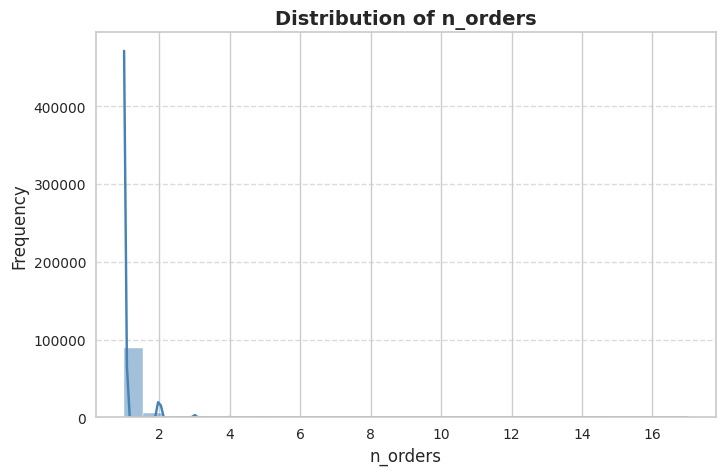

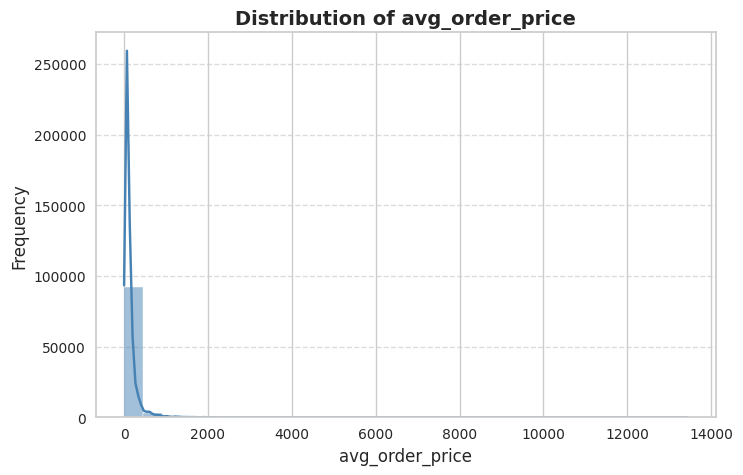

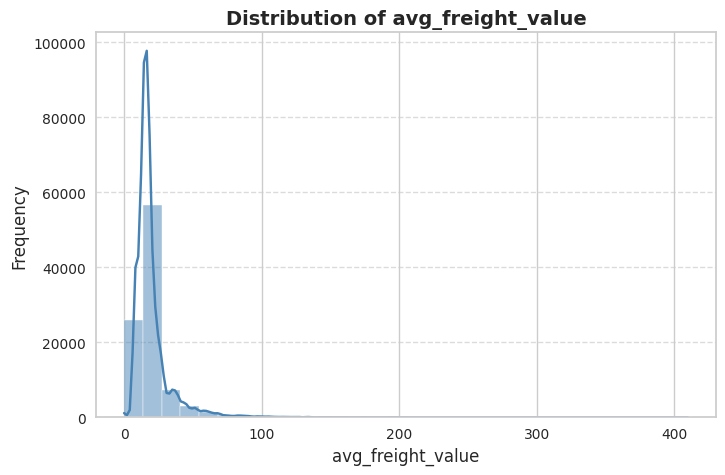

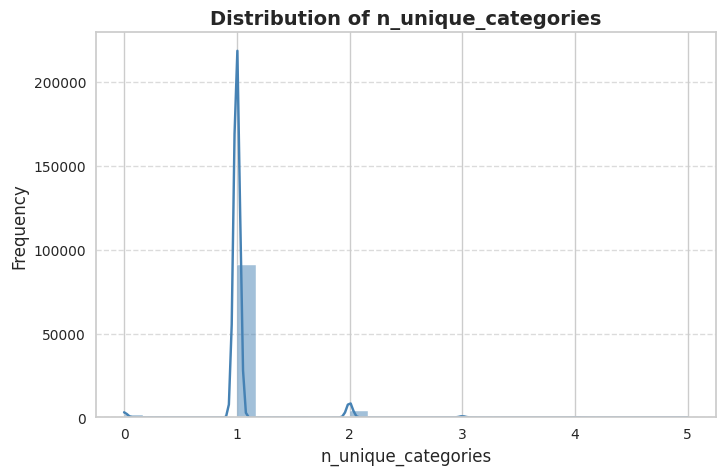

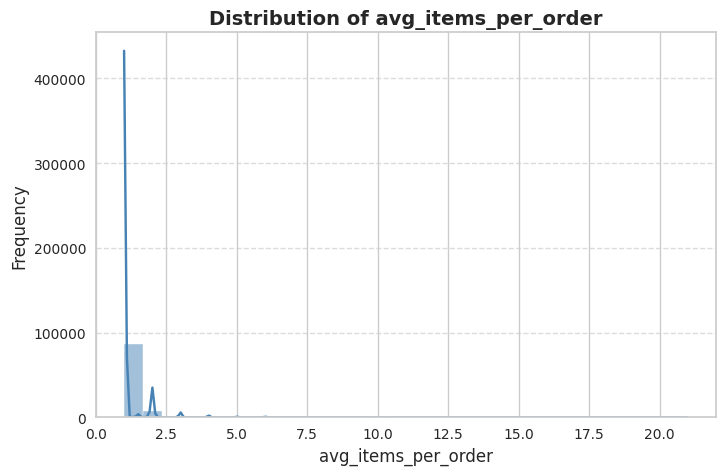

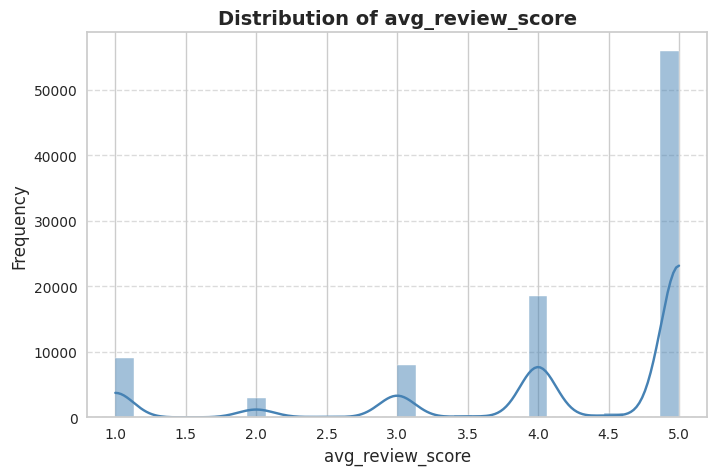

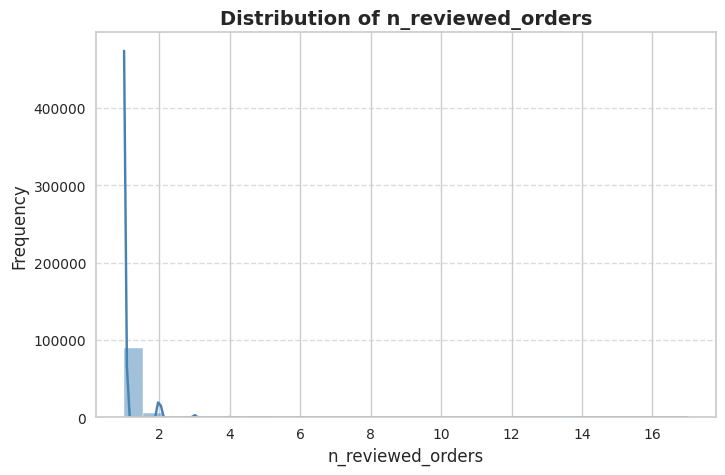

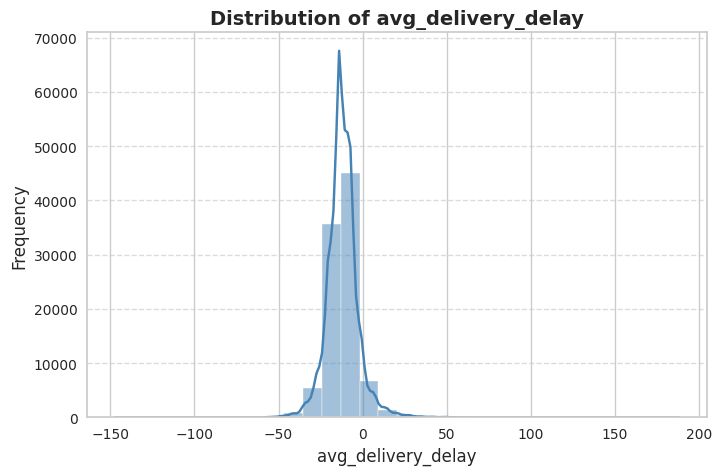

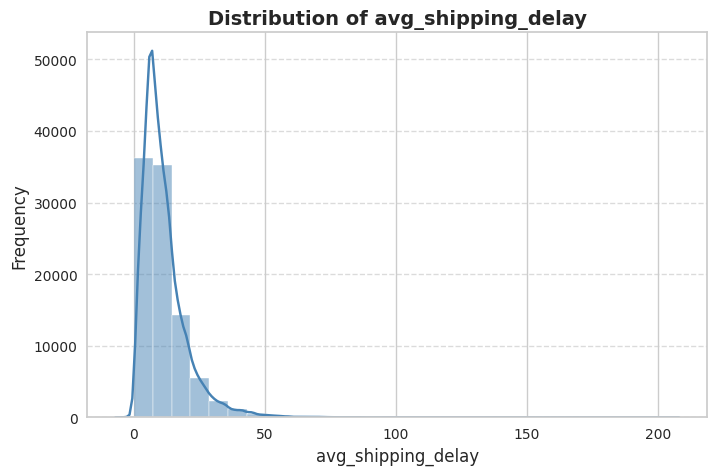

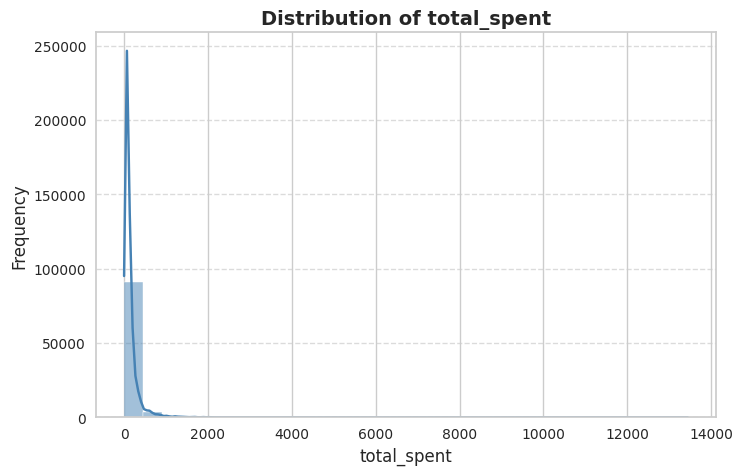

In [ ]:
sns.set_style("whitegrid")

features_to_plot = ['n_orders', 'avg_order_price', 'avg_freight_value', 'n_unique_categories',
    'avg_items_per_order', 'avg_review_score', 'n_reviewed_orders',
    'avg_delivery_delay', 'avg_shipping_delay', 'total_spent']

for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], bins=30, kde=True, color='steelblue')
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


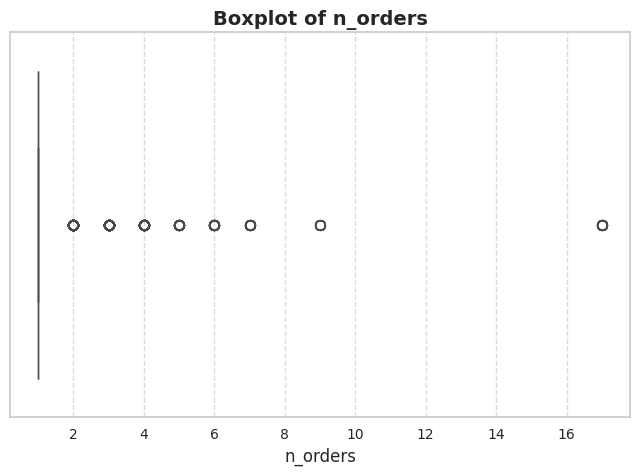

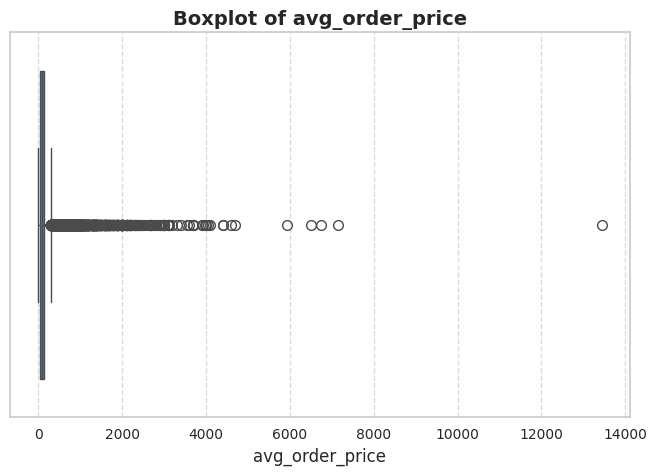

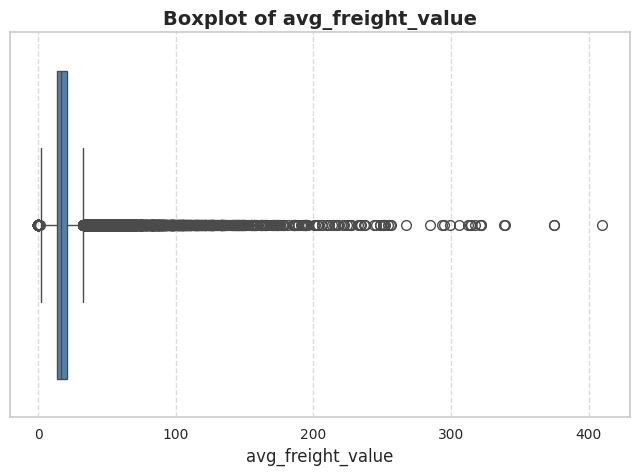

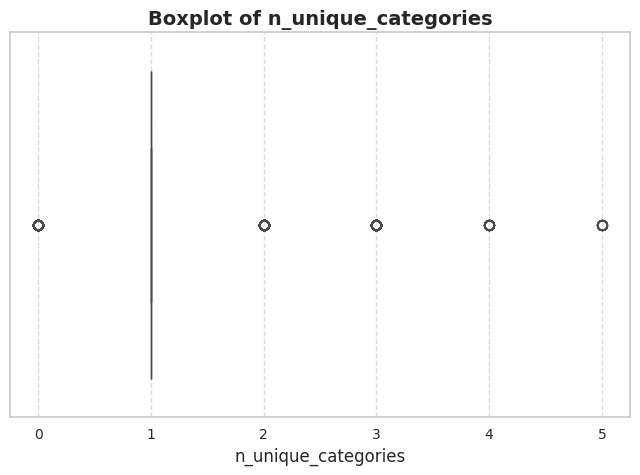

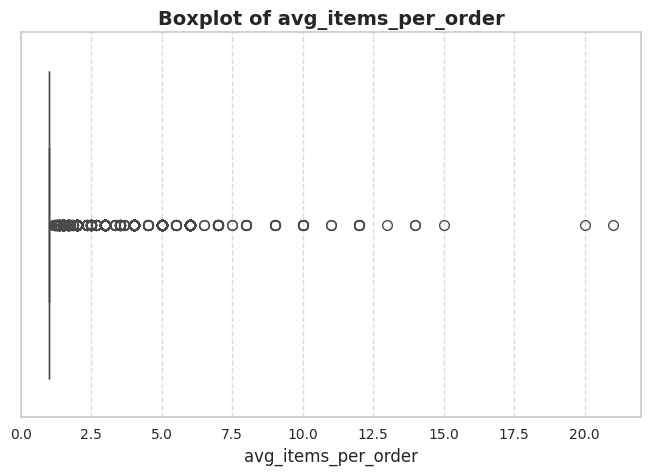

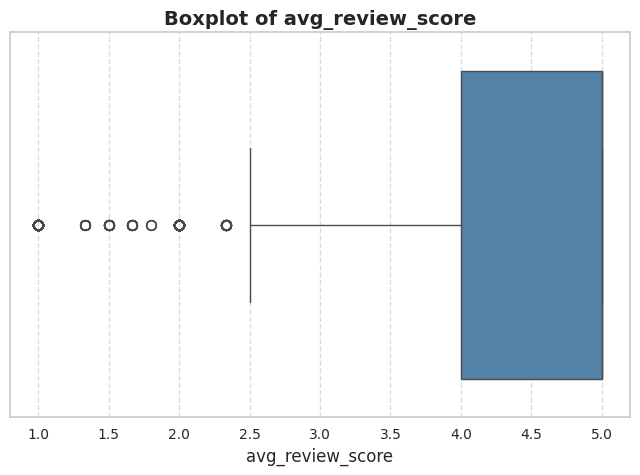

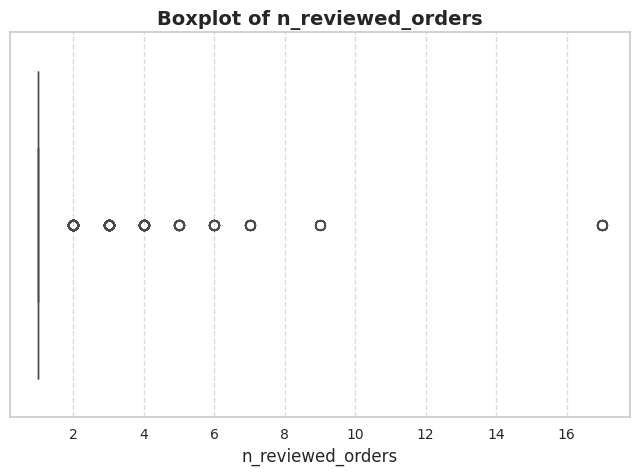

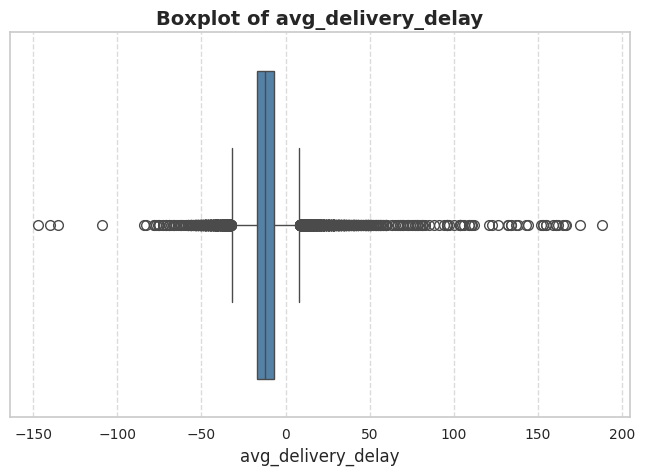

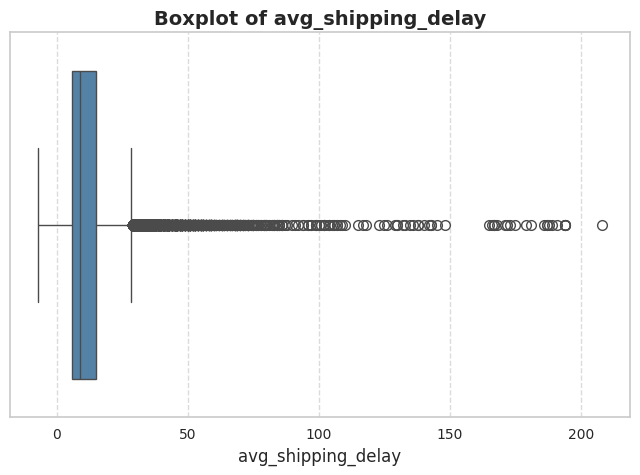

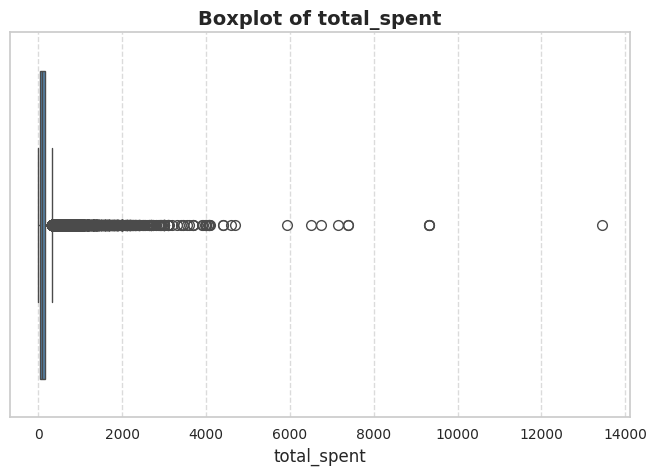

In [ ]:
for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color='steelblue')
    plt.title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

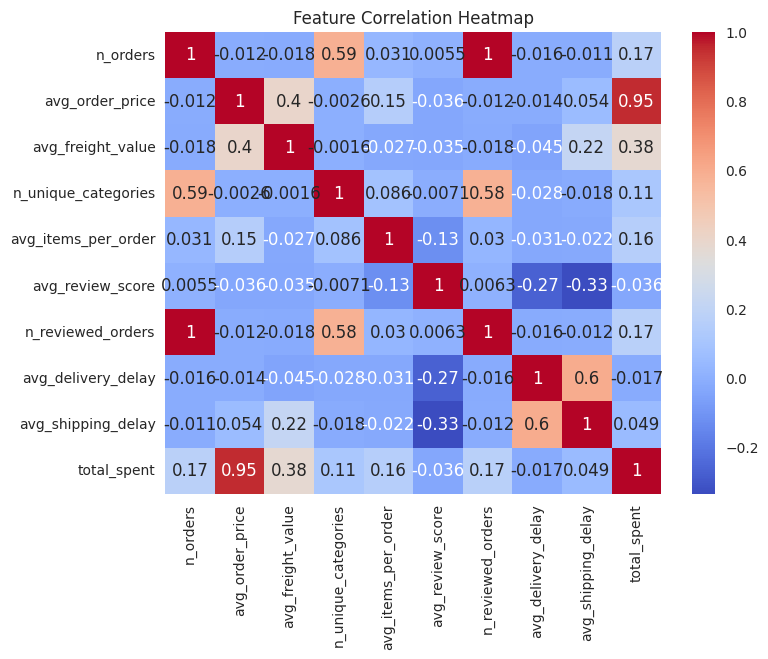

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features_to_plot].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

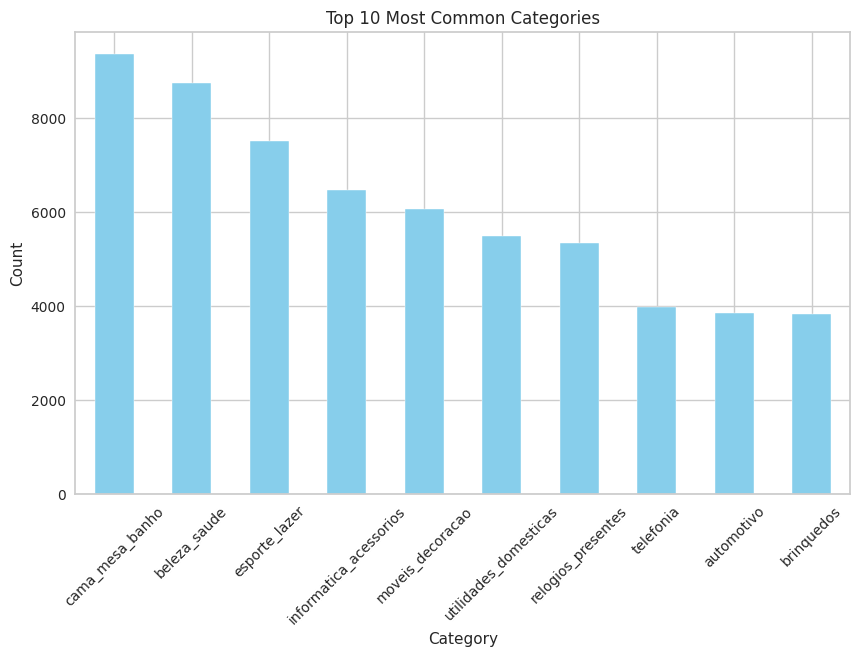

In [ ]:
top_categories = df['top_category'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_categories.plot(kind='bar', color='skyblue')

plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Top 10 Most Common Categories')
plt.xticks(rotation=45)

plt.show()

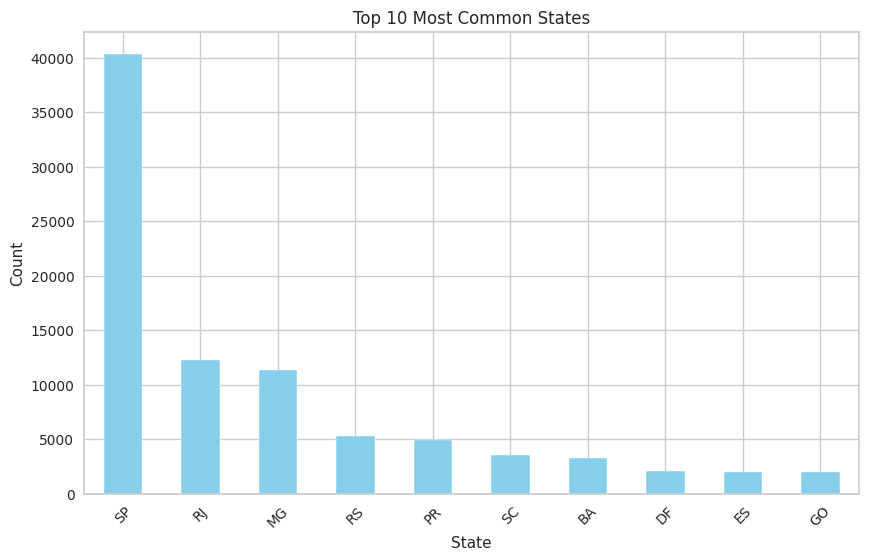

In [ ]:
top_states = df['customer_state'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_states.plot(kind='bar', color='skyblue')

plt.xlabel('State')
plt.ylabel('Count')
plt.title('Top 10 Most Common States')
plt.xticks(rotation=45)

plt.show()

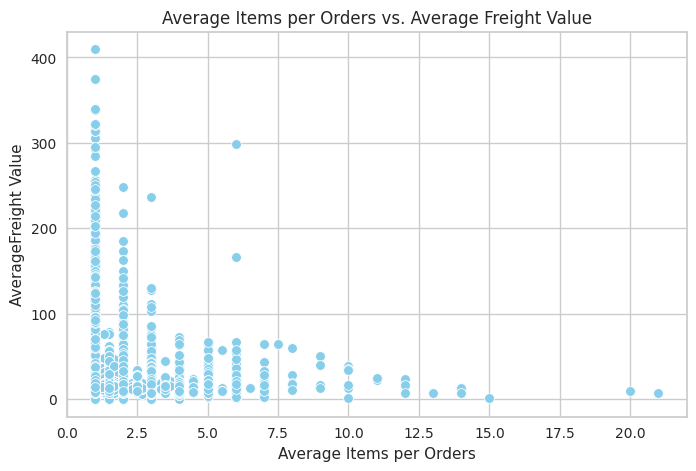

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='avg_items_per_order', y='avg_freight_value', data=df, color='skyblue')
plt.title('Average Items per Orders vs. Average Freight Value')
plt.xlabel('Average Items per Orders')
plt.ylabel('AverageFreight Value')
plt.show()

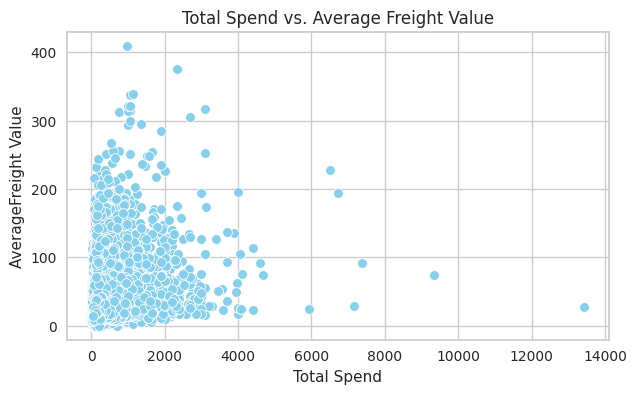

In [ ]:
plt.figure(figsize=(7,4))
sns.scatterplot(x='total_spent', y='avg_freight_value', data=df, color='skyblue')
plt.title('Total Spend vs. Average Freight Value')
plt.xlabel('Total Spend')
plt.ylabel('AverageFreight Value')
plt.show()

In [ ]:
# because of high correlation with other features, they are dropped to reduce the dimensionality.
df = df.drop(columns=['n_reviewed_orders'])
df = df.drop(columns=['avg_order_price']) # corr=0.95 with total_spend

In [ ]:
df = df.drop(columns=['avg_delivery_delay']) # corr=0.6 with avg_shipping_delay

In [ ]:
df = df.drop(columns=['customer_city'])

In [ ]:
print(df['top_category'].value_counts())

top_category
cama_mesa_banho                  9359
beleza_saude                     8754
esporte_lazer                    7513
informatica_acessorios           6467
moveis_decoracao                 6063
                                 ... 
cds_dvds_musicais                  12
la_cuisine                          9
pc_gamer                            6
fashion_roupa_infanto_juvenil       5
seguros_e_servicos                  2
Name: count, Length: 74, dtype: int64


In [ ]:
df.head()

,customer_unique_id,n_orders,avg_freight_value,n_unique_categories,top_category,avg_items_per_order,avg_review_score,avg_shipping_delay,customer_state,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,1,12.00,1.0,cama_mesa_banho,1.0,5.0,6.0,SP,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,8.29,1.0,beleza_saude,1.0,4.0,2.0,SP,18.90
2,0000f46a3911fa3c0805444483337064,1,17.22,1.0,papelaria,1.0,3.0,25.0,SC,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,1,17.63,1.0,telefonia,1.0,4.0,20.0,PA,25.99
4,0004aac84e0df4da2b147fca70cf8255,1,16.89,1.0,telefonia,1.0,5.0,13.0,SP,180.00


In [ ]:
df.dtypes

,0
customer_unique_id,object
n_orders,int64
avg_freight_value,float64
n_unique_categories,float64
top_category,object
avg_items_per_order,float64
avg_review_score,float64
avg_shipping_delay,float64
customer_state,object
total_spent,float64


#### 6. Handling Outliers and Feature Engineering

In [ ]:
# Define threshold - here 100
threshold = 100

# Get counts
counts = df['top_category'].value_counts()

# Categories to keep
categories_to_keep = counts[counts >= threshold].index

# Map rare categories to 'Other'
df['top_category'] = df['top_category'].apply(
    lambda x: x if x in categories_to_keep else 'Other'
)

In [ ]:
# Add VIP-spending pattern flag (1 if total_spent above 75th percentile, else 0)
threshold = df['total_spent'].quantile(0.75)
df['VIP'] = (df['total_spent'] > threshold).astype(int)

df.head()

,customer_unique_id,n_orders,avg_freight_value,n_unique_categories,top_category,avg_items_per_order,avg_review_score,avg_shipping_delay,customer_state,total_spent,VIP
0,0000366f3b9a7992bf8c76cfdf3221e2,1,12.00,1.0,cama_mesa_banho,1.0,5.0,6.0,SP,129.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,8.29,1.0,beleza_saude,1.0,4.0,2.0,SP,18.90,0
2,0000f46a3911fa3c0805444483337064,1,17.22,1.0,papelaria,1.0,3.0,25.0,SC,69.00,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,17.63,1.0,telefonia,1.0,4.0,20.0,PA,25.99,0
4,0004aac84e0df4da2b147fca70cf8255,1,16.89,1.0,telefonia,1.0,5.0,13.0,SP,180.00,1


In [ ]:
state_freq = df['customer_state'].value_counts(normalize=True)
df['state_freq'] = df['customer_state'].map(state_freq)

In [ ]:
df['top_category'] = df['top_category'].apply(
    lambda x: x[0] if isinstance(x, (np.ndarray, pd.Series, list)) else x
)
cat_freq = df['top_category'].value_counts(normalize=True)
df['category_freq'] = df['top_category'].map(cat_freq)

In [ ]:
df.drop(['customer_state', 'top_category'], axis=1, inplace=True)
df.head()

,customer_unique_id,n_orders,avg_freight_value,n_unique_categories,avg_items_per_order,avg_review_score,avg_shipping_delay,total_spent,VIP,state_freq,category_freq
0,0000366f3b9a7992bf8c76cfdf3221e2,1,12.00,1.0,1.0,5.0,6.0,129.90,0,0.420161,0.097433
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,8.29,1.0,1.0,4.0,2.0,18.90,0,0.420161,0.091134
2,0000f46a3911fa3c0805444483337064,1,17.22,1.0,1.0,3.0,25.0,69.00,0,0.036708,0.022945
3,0000f6ccb0745a6a4b88665a16c9f078,1,17.63,1.0,1.0,4.0,20.0,25.99,0,0.009744,0.041372
4,0004aac84e0df4da2b147fca70cf8255,1,16.89,1.0,1.0,5.0,13.0,180.00,1,0.420161,0.041372


In [ ]:
numeric_cols = ['total_spent', 'avg_review_score', 'avg_shipping_delay', 'avg_freight_value', 'avg_items_per_order', 'n_unique_categories', 'state_freq', 'category_freq']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

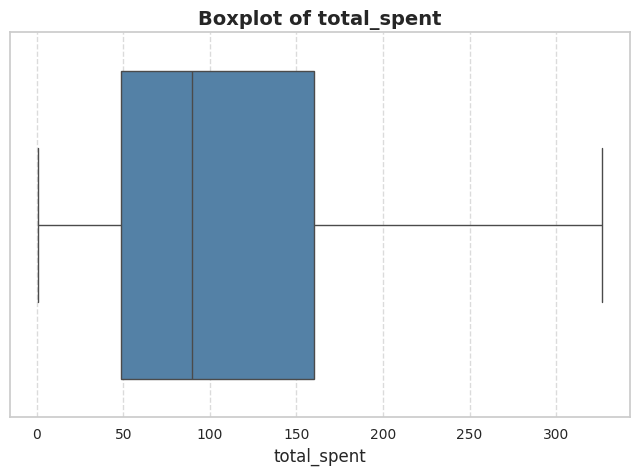

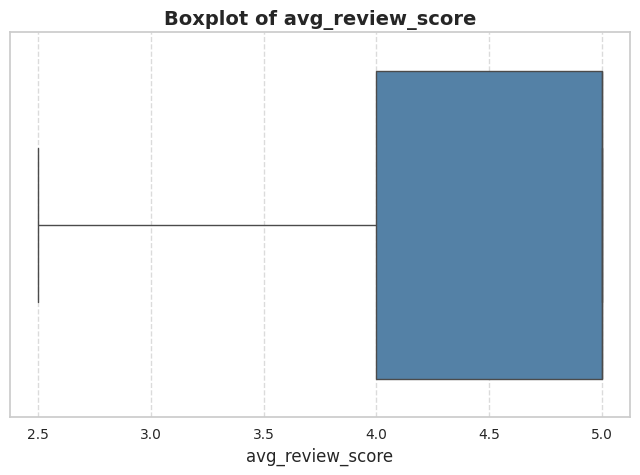

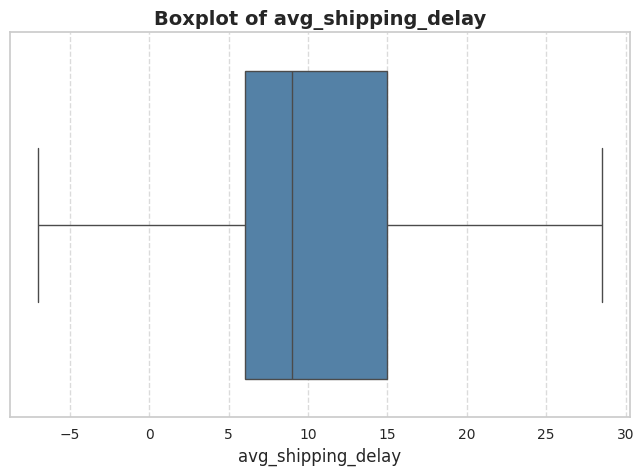

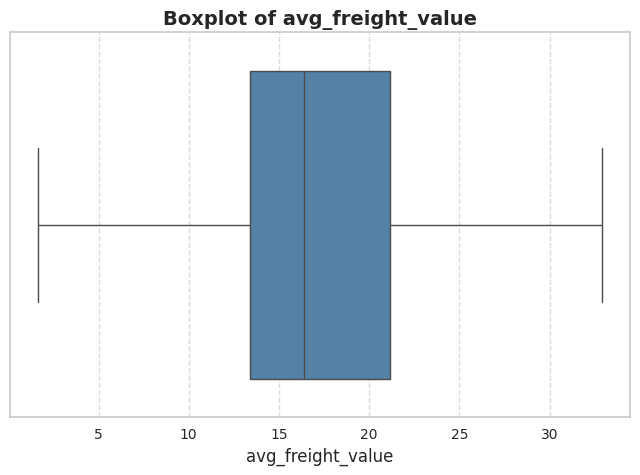

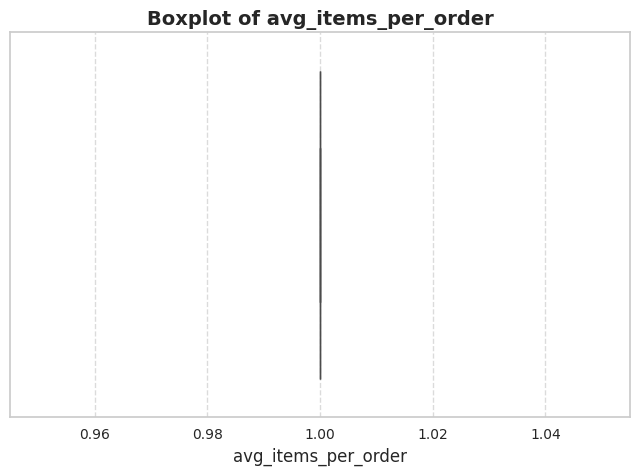

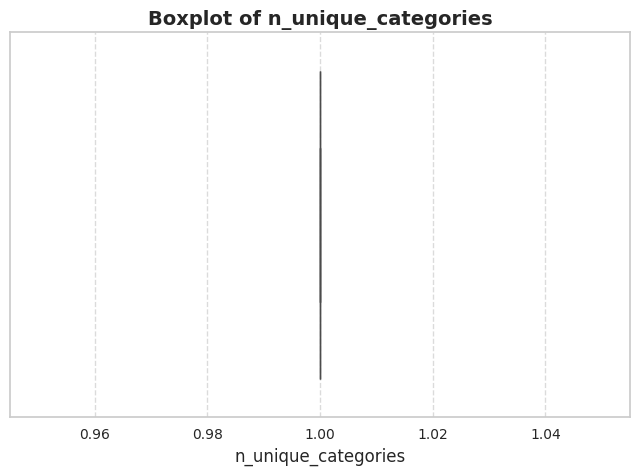

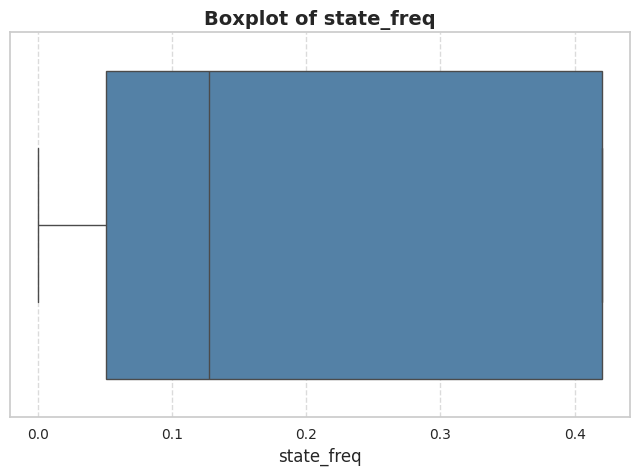

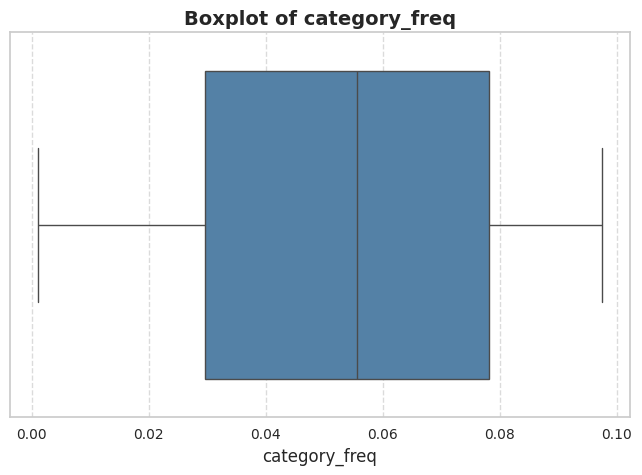

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color='steelblue')
    plt.title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

#### 7. Clustering with Kmeans

In [ ]:
numeric_cols_edited = ['total_spent', 'avg_review_score', 'avg_shipping_delay', 'avg_freight_value', 'avg_items_per_order', 'n_unique_categories']

In [ ]:
X2 = df[numeric_cols_edited]
scaler = StandardScaler()
X_scaled2 = scaler.fit_transform(X2)

In [ ]:
X = df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

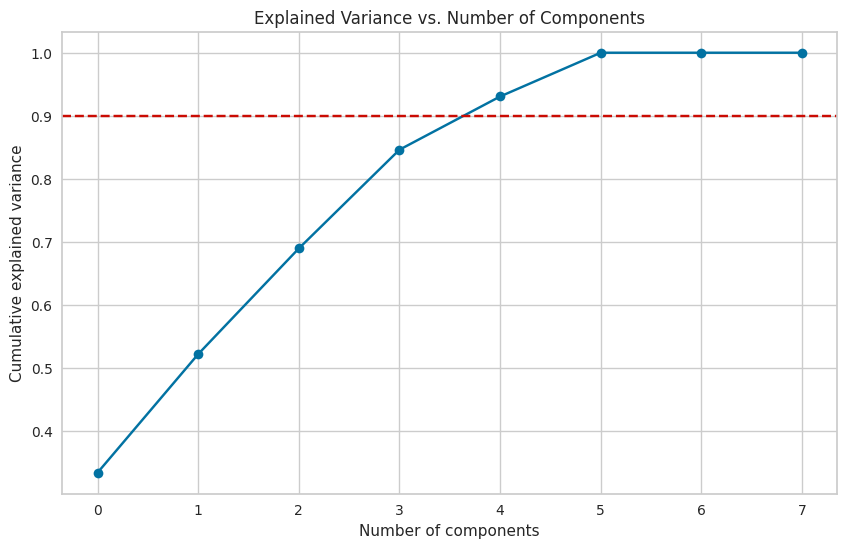

In [ ]:
pca = PCA()
pca.fit(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='--')  # Optional: highlight 90% line
plt.show()

In [ ]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of components to retain 90% variance: {n_components_90}")

Number of components to retain 90% variance: 5


In [ ]:
pca = PCA(n_components=5, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

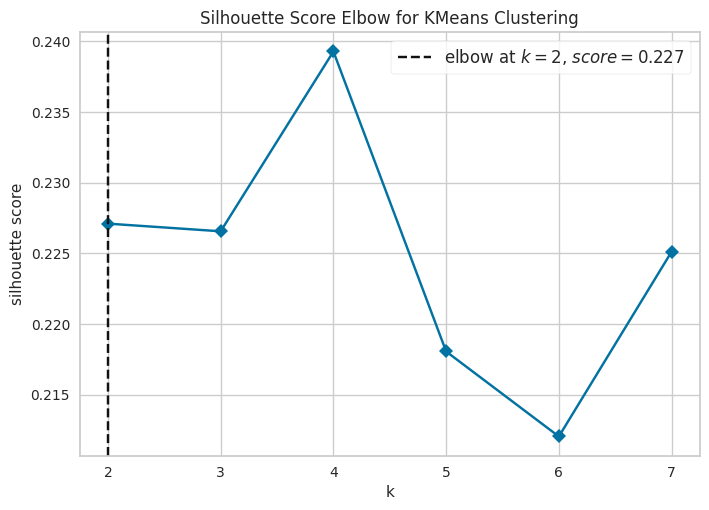

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:

# Create Elbow Visualizer using silhouette metric
model = KMeans(init='k-means++', random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 8), metric='silhouette', timings=False)

# Fit and show
visualizer.fit(X_reduced)
visualizer.show()


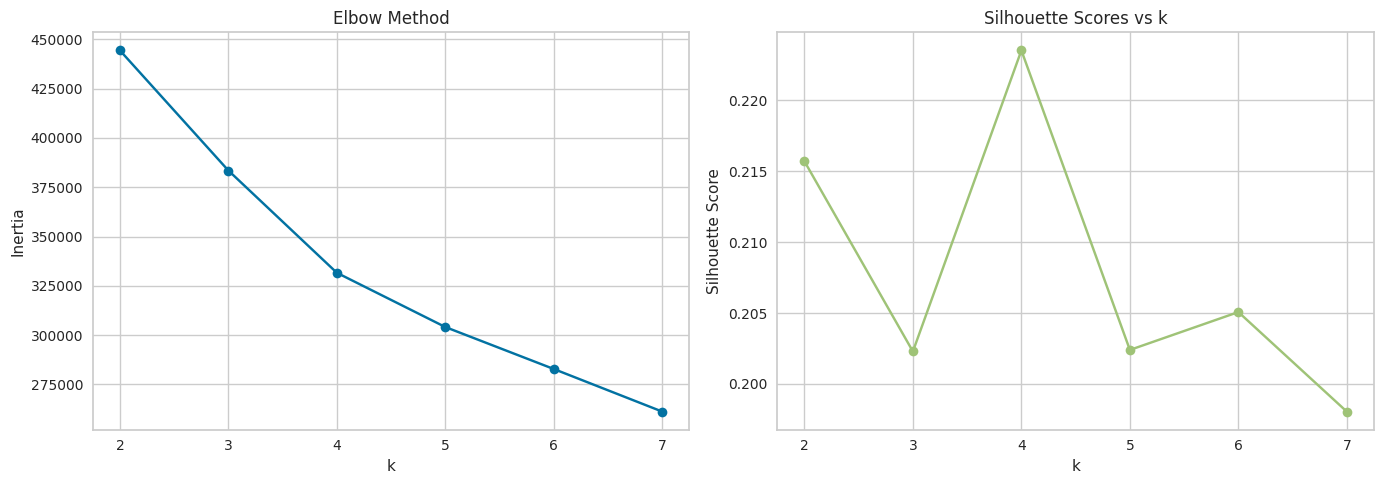

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(init='k-means++', n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores vs k')

plt.tight_layout()
plt.show()

In [ ]:
k_choice = 4
kmeans_final = KMeans(n_clusters=k_choice, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df['cluster'] = cluster_labels

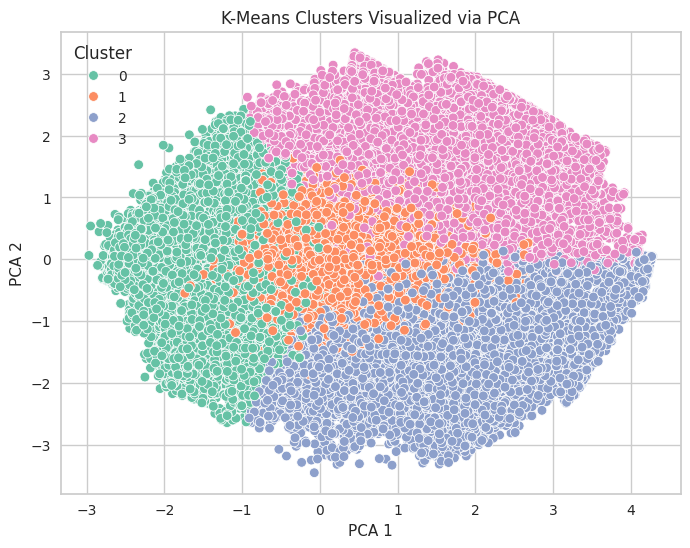

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='Set2')
plt.title('K-Means Clusters Visualized via PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

In [ ]:
db_score = davies_bouldin_score(X_scaled, df['cluster'])
print(f'Davies–Bouldin Score: {db_score:.3f}')

Davies–Bouldin Score: 1.513


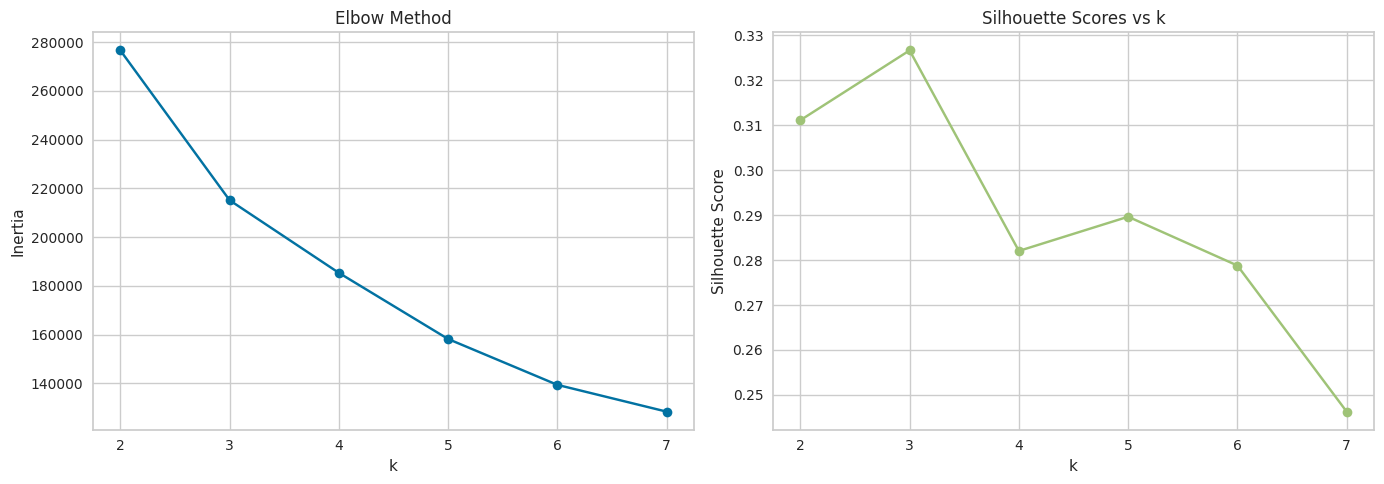

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(init='k-means++', n_clusters=k, random_state=42)
    kmeans.fit(X_scaled2)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled2, kmeans.labels_))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores vs k')

plt.tight_layout()
plt.show()

In [ ]:
k_choice = 3
kmeans_final = KMeans(n_clusters=k_choice, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled2)

df['cluster'] = cluster_labels

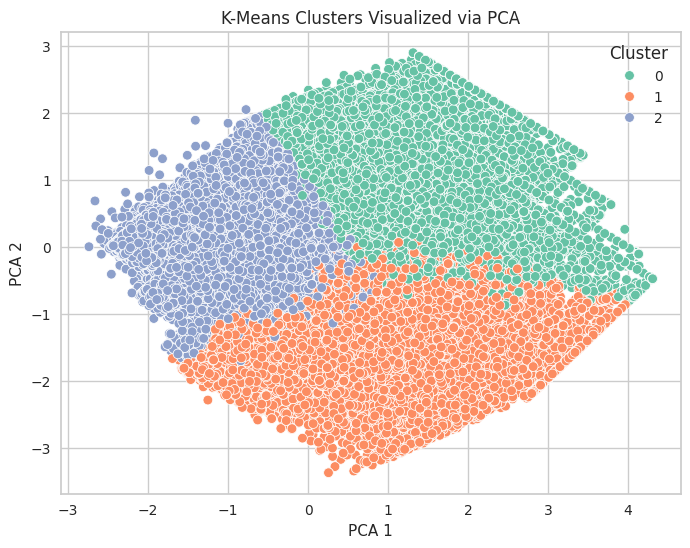

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled2)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='Set2')
plt.title('K-Means Clusters Visualized via PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

In [ ]:
db_score = davies_bouldin_score(X_scaled2, df['cluster'])
print(f'Davies–Bouldin Score: {db_score:.3f}')

Davies–Bouldin Score: 1.286


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

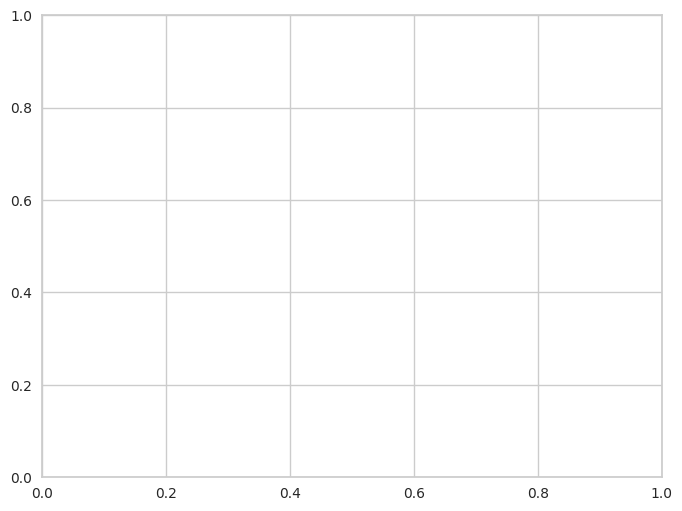

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled2)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], data=df, cmap='tab10')
plt.title("t-SNE Visualization of Clusters")
plt.show()

In [85]:
df.head()

,customer_unique_id,n_orders,avg_freight_value,n_unique_categories,avg_items_per_order,avg_review_score,avg_shipping_delay,total_spent,VIP,state_freq,category_freq,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,1,12.00,1.0,1.0,5.0,6.0,129.90,0,0.420161,0.097433,2
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,8.29,1.0,1.0,4.0,2.0,18.90,0,0.420161,0.091134,2
2,0000f46a3911fa3c0805444483337064,1,17.22,1.0,1.0,3.0,25.0,69.00,0,0.036708,0.022945,1
3,0000f6ccb0745a6a4b88665a16c9f078,1,17.63,1.0,1.0,4.0,20.0,25.99,0,0.009744,0.041372,1
4,0004aac84e0df4da2b147fca70cf8255,1,16.89,1.0,1.0,5.0,13.0,180.00,1,0.420161,0.041372,2


#### 8. Model Variants

In [86]:
X_sample = X_scaled[:10000]

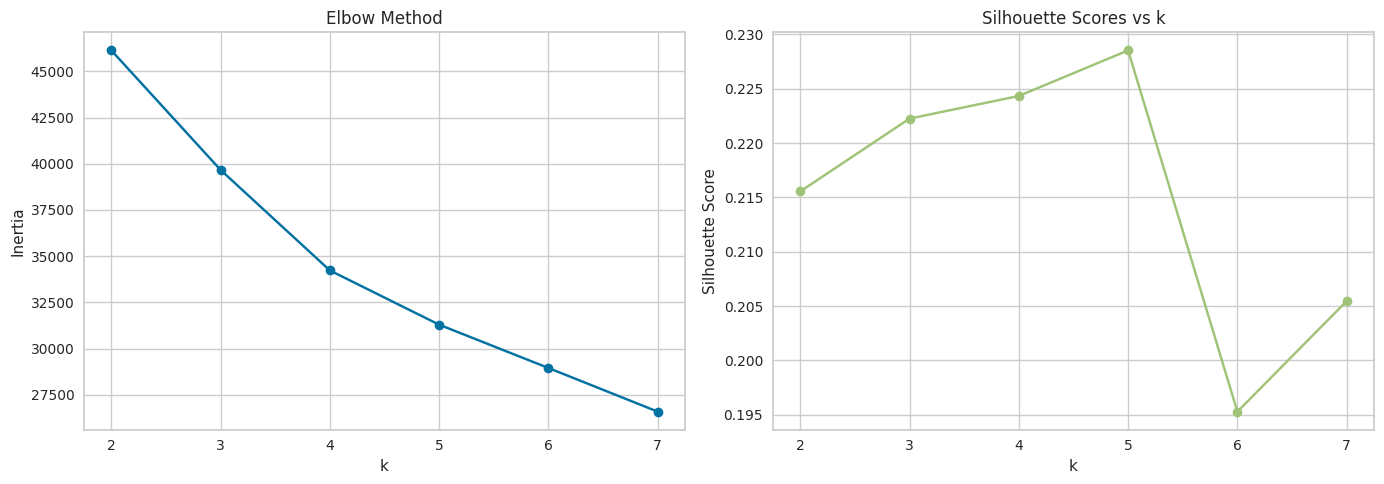

In [87]:
inertia = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(init='k-means++', n_clusters=k, random_state=42)
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, kmeans.labels_))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores vs k')

plt.tight_layout()
plt.show()

In [88]:
k_choice = 4
kmeans_final = KMeans(n_clusters=k_choice, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_sample)

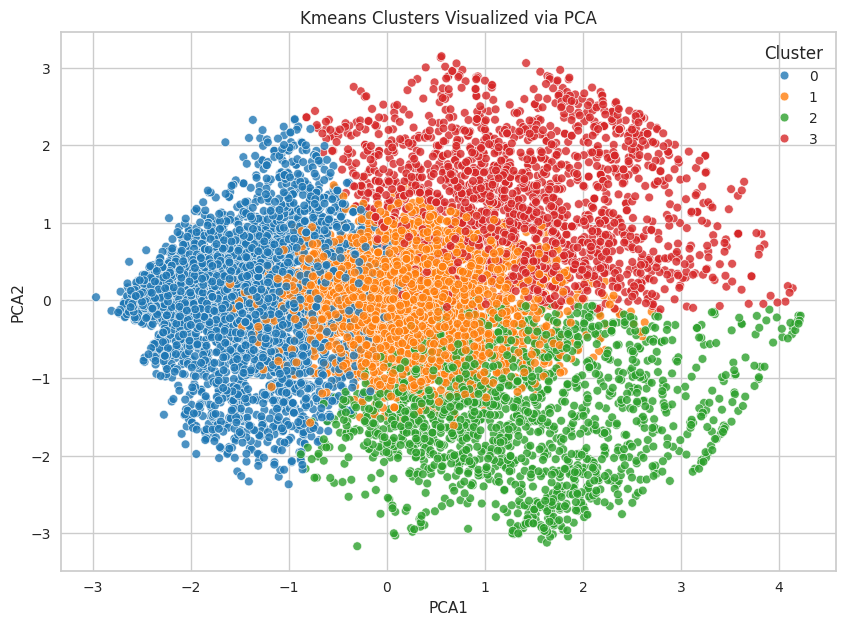

In [89]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=40, alpha=0.8)
plt.title('Kmeans Clusters Visualized via PCA')
plt.legend(title='Cluster')
plt.show()

In [90]:
kmeans_silhouette = silhouette_score(X_sample, cluster_labels)
kmeans_db_score = davies_bouldin_score(X_sample, cluster_labels)

In [91]:
print(f"K-Means Results on Sample (n=10,000):")
print(f"→ Silhouette Score: {kmeans_silhouette:.3f}")
print(f"→ Davies-Bouldin Score: {kmeans_db_score:.3f}")

K-Means Results on Sample (n=10,000):
→ Silhouette Score: 0.224
→ Davies-Bouldin Score: 1.507


In [92]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_sample)

In [93]:
mask = dbscan_labels != -1
if mask.sum() > 1:
    dbscan_silhouette = silhouette_score(X_sample[mask], dbscan_labels[mask])
    dbscan_db_score = davies_bouldin_score(X_sample[mask], dbscan_labels[mask])

    print(f"DBSCAN Results on Sample (n=10,000):")
    print(f"→ Silhouette Score: {dbscan_silhouette:.3f}")
    print(f"→ Davies-Bouldin Score: {dbscan_db_score:.3f}")
else:
    print("DBSCAN labeled all or most points as noise. Try lowering eps.")

DBSCAN Results on Sample (n=10,000):
→ Silhouette Score: -0.033
→ Davies-Bouldin Score: 1.069


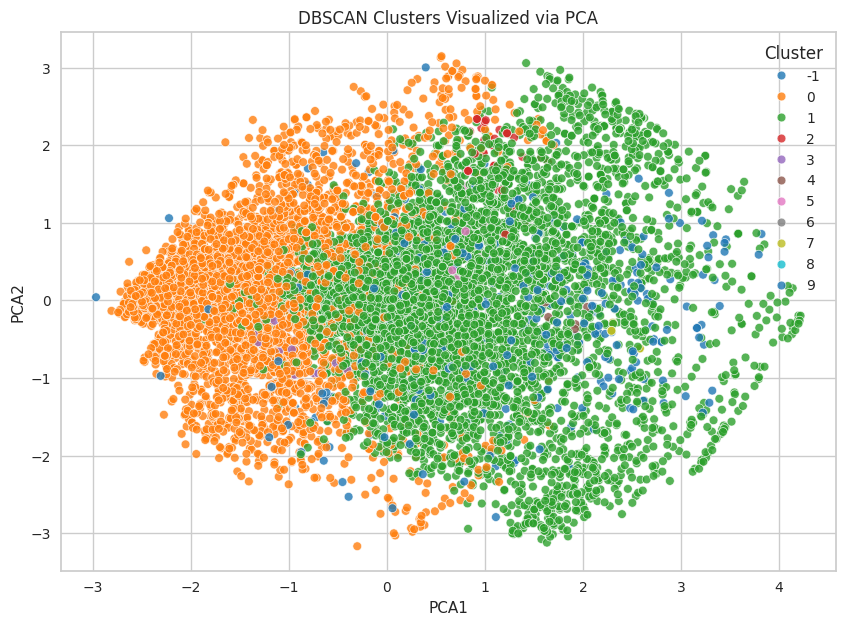

In [94]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = dbscan_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=40, alpha=0.8)
plt.title('DBSCAN Clusters Visualized via PCA')
plt.legend(title='Cluster')
plt.show()

#### 9. Cluster Profiling and Business Insight

In [96]:
df.dtypes

,0
customer_unique_id,object
n_orders,int64
avg_freight_value,float64
n_unique_categories,float64
avg_items_per_order,float64
avg_review_score,float64
avg_shipping_delay,float64
total_spent,float64
VIP,int64
state_freq,float64


In [109]:
cluster_summary = df.groupby('cluster').agg({
    'total_spent': 'mean',
    'n_orders': 'mean',
    'avg_review_score': 'mean',
    'avg_freight_value': 'mean',
    'n_unique_categories': 'mean',
    'avg_items_per_order': 'mean',
    'avg_shipping_delay': 'mean',
    'customer_unique_id': 'count'  # cluster size
}).rename(columns={'customer_unique_id': 'n_customers'})
cluster_summary.head()

,total_spent,n_orders,avg_review_score,avg_freight_value,n_unique_categories,avg_items_per_order,avg_shipping_delay,n_customers
cluster,,,,,,,,
0,224.270012,1.159764,4.566195,26.052690,1.0,1.0,12.794511,23685
1,102.727164,1.068752,2.901682,17.638377,1.0,1.0,15.913114,21352
2,76.264407,1.050256,4.779563,14.341413,1.0,1.0,8.218036,51019


In [111]:
cluster_summary.dtypes

,0
total_spent,float64
n_orders,float64
avg_review_score,float64
avg_freight_value,float64
n_unique_categories,float64
avg_items_per_order,float64
avg_shipping_delay,float64
n_customers,int64


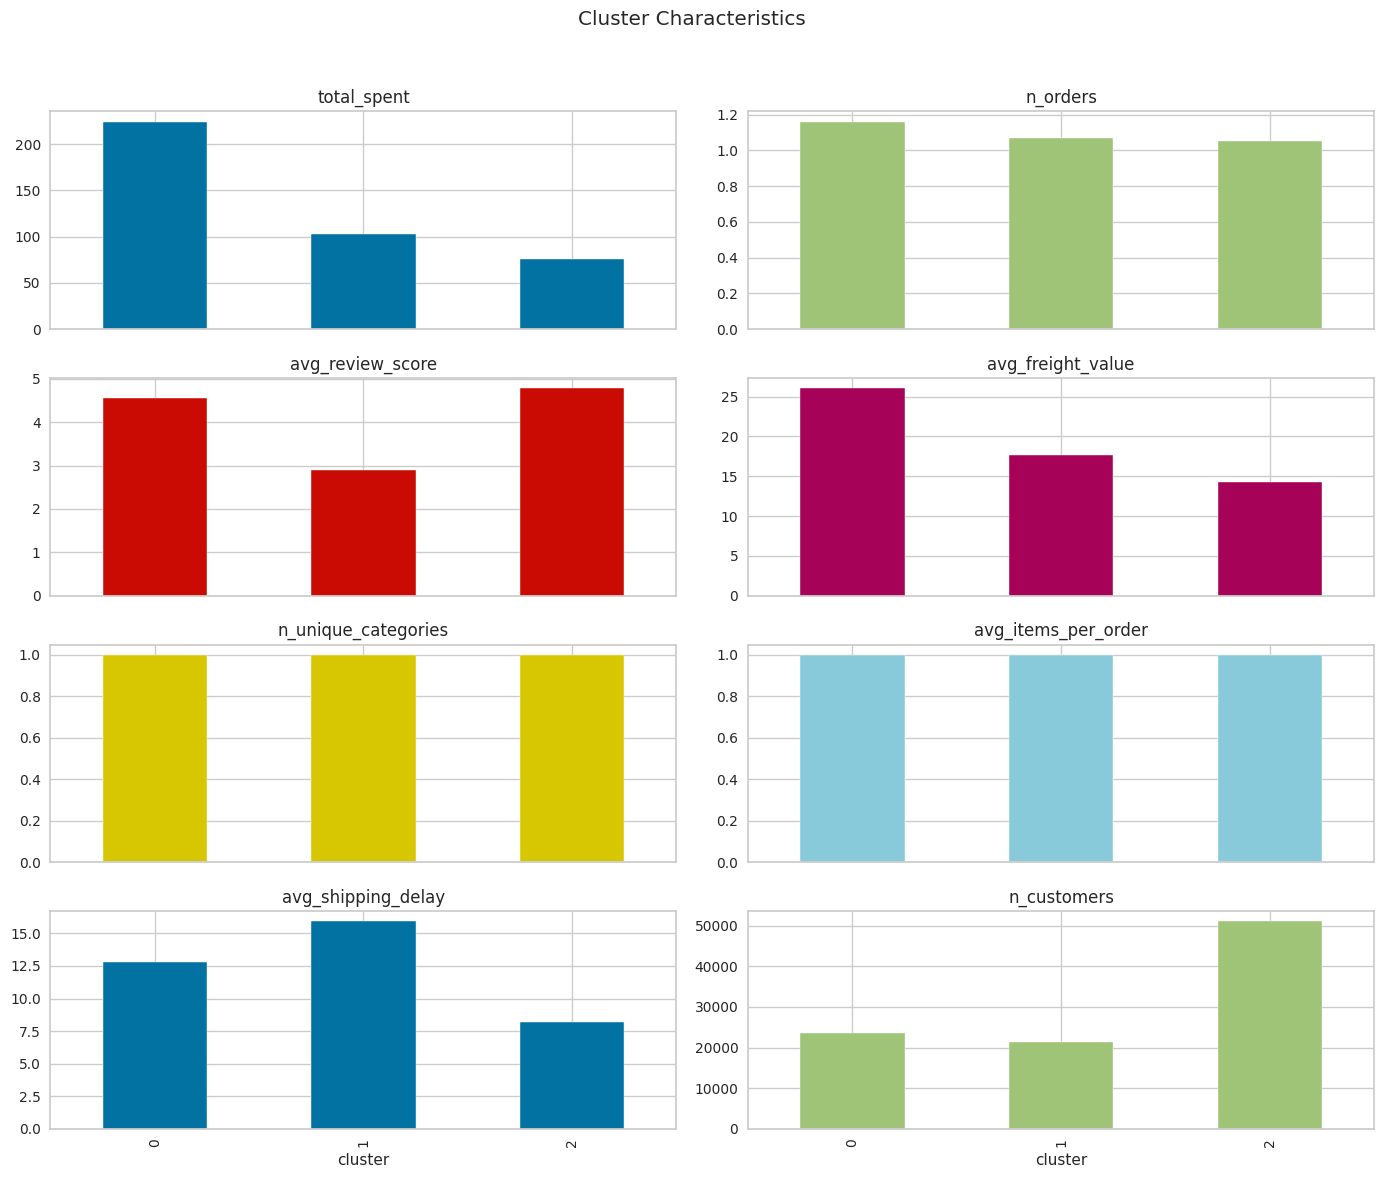

In [110]:
cluster_summary.plot(kind='bar', subplots=True, layout=(4, 2), figsize=(14, 12), sharex=True, legend=False)

plt.suptitle('Cluster Characteristics')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
plt.show()